In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_tasks = 1000

dataset = pd.DataFrame({
    'task_length': np.random.normal(500, 150, n_tasks).astype(int),
    'cpu_cores_needed': np.random.randint(1, 8, n_tasks),
    'memory_needed(MB)': np.random.normal(1024, 256, n_tasks).astype(int),
    'network_bandwidth_needed(Mbps)': np.random.normal(100, 20, n_tasks).astype(int),
    'priority': np.random.choice([1,2,3], n_tasks),
    'vm_id': np.random.choice(['VM1','VM2','VM3','VM4'], n_tasks),
    'arrival_time': np.cumsum(np.random.exponential(300, n_tasks)).astype(int)
})

# Save to CSV
dataset.to_csv('optimized_tasks_vms.csv', index=False)


2025-03-14 14:43:42,188 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Dataset preview (after processing):
   task_length  cpu_cores_needed  memory_needed(MB)  \
0          574                 7               1311   
1          479                 4                819   
2          597                 1               1099   
3          728                 3                584   
4          464                 5                885   

   network_bandwidth_needed(Mbps)  priority  vm_id  
0                             118         2      3  
1                              86         1      1  
2                             106         1      0  
3                              50         2      3  
4                             119         1      3  
Training data shape: (792, 10, 6) with 6 features per time step.


pyswarms.single.global_best:   0%|          |0/10c:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
pyswarms.single.global_best: 100%|██████████|10/10, best_cost=0.018
2025-03-14 14:48:11,023 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.018001532182097435, best pos: [6.92842472e+01 2.71975592e-01 9.20747086e-03]


Best PSO parameters found: [6.92842472e+01 2.71975592e-01 9.20747086e-03]
Best GA parameters found: [7.60737269e+01 2.10141035e-01 5.26101212e-03]
PSO validation loss: 0.01919783279299736 GA validation loss: 0.020630428567528725
Using PSO parameters for final model.
Final model hyperparameters: units=69, dropout=0.272, learning_rate=0.00921
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0858 - val_loss: 0.0194
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0251 - val_loss: 0.0187
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0244 - val_loss: 0.0223
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0214 - val_loss: 0.0185
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0217 - val_loss: 0.0186
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0208 - val_loss: 0.0183
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0216 - val_loss: 0.0191
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0200 - v

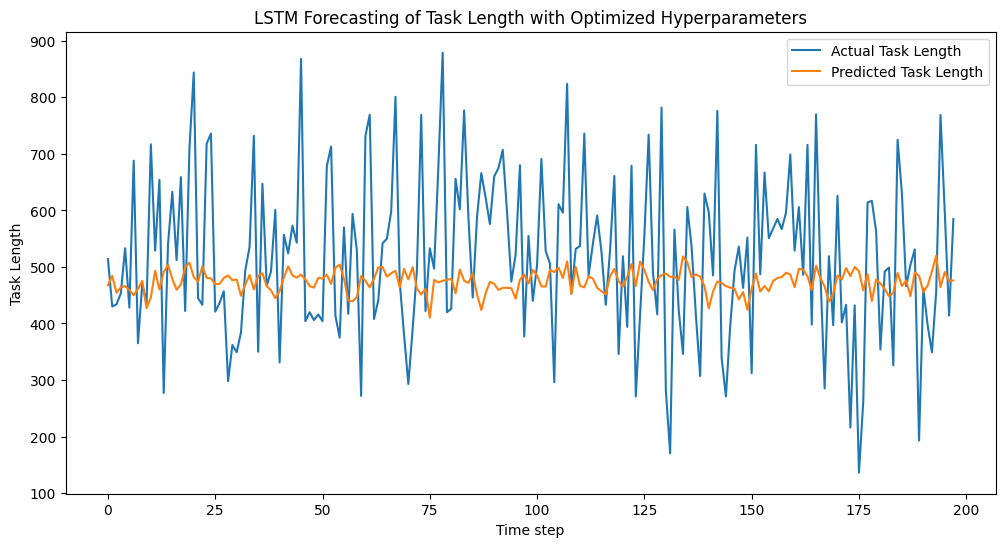

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# For hyperparameter optimization
import pyswarms as ps
import pygad


df = pd.read_csv('optimized_tasks_vms.csv')

# Sort by arrival_time to maintain the order of task arrivals
df = df.sort_values(by='arrival_time')

# Encode vm_id as numeric (if needed). Alternatively, drop it if not useful.
df['vm_id'] = df['vm_id'].astype('category').cat.codes

# Drop arrival_time since it's used only for ordering
df_features = df.drop(columns=['arrival_time'])

print("Dataset preview (after processing):")
print(df_features.head())

# The dataset now has the following columns:
# task_length, cpu_cores_needed, memory_needed(MB), network_bandwidth_needed(Mbps), priority, vm_id
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_features)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])  # target is task_length
    return np.array(X), np.array(y)

# Choose a window size (adjust as needed)
window_size = 10
X, y = create_sequences(scaled_data, window_size)

# %% [code]
# Split data into training and testing sets (80/20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Number of features per time step (should be 6)
num_features = X.shape[2]
print(f"Training data shape: {X_train.shape} with {num_features} features per time step.")

# %% [code]
# Function to build the LSTM model using hyperparameters.
def build_lstm_model(units, dropout_rate, learning_rate):
    model = Sequential()
    model.add(LSTM(units, input_shape=(window_size, num_features)))
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model

# %% [code]
# Define the objective function for PSO.
# Each particle represents [units, dropout_rate, learning_rate].
def pso_objective(params):
    losses = []
    for param in params:
        units = int(param[0])
        dropout_rate = param[1]
        learning_rate = param[2]
        
        model = build_lstm_model(units, dropout_rate, learning_rate)
        # Train briefly for quick evaluation
        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
        loss = model.evaluate(X_test, y_test, verbose=0)
        losses.append(loss)
    return np.array(losses)

# %% [code]
# Set up PSO optimization.
lower_bounds = [10, 0.0, 0.0001]    # [units, dropout_rate, learning_rate]
upper_bounds = [100, 0.5, 0.01]
bounds = (np.array(lower_bounds), np.array(upper_bounds))
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=3, options=options, bounds=bounds)
best_cost, best_pos = optimizer.optimize(pso_objective, iters=10)
print("Best PSO parameters found:", best_pos)

# %% [code]
# Define the fitness function for GA.
# IMPORTANT: pygad expects the fitness function to accept three arguments:
# (ga_instance, solution, solution_idx)
def ga_fitness_func(ga_instance, solution, solution_idx):
    units = int(solution[0])
    dropout_rate = solution[1]
    learning_rate = solution[2]
    model = build_lstm_model(units, dropout_rate, learning_rate)
    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    loss = model.evaluate(X_test, y_test, verbose=0)
    # Return inverse loss since pygad maximizes fitness.
    fitness = 1.0 / (loss + 1e-6)
    return fitness

# %% [code]
# Set up GA optimization.
gene_space = [
    {'low': 10, 'high': 100},         # units
    {'low': 0.0, 'high': 0.5},          # dropout_rate
    {'low': 0.0001, 'high': 0.01}       # learning_rate
]

ga_instance = pygad.GA(num_generations=10,
                       num_parents_mating=5,
                       fitness_func=ga_fitness_func,
                       sol_per_pop=10,
                       num_genes=3,
                       gene_space=gene_space,
                       mutation_probability=0.1,
                       crossover_probability=0.5,
                       mutation_type="random")

ga_instance.run()
ga_solution, ga_solution_fitness, ga_solution_idx = ga_instance.best_solution()
print("Best GA parameters found:", ga_solution)

# %% [code]
# Evaluate a given set of hyperparameters by training a model briefly.
def evaluate_params(params):
    units = int(params[0])
    dropout_rate = params[1]
    learning_rate = params[2]
    model = build_lstm_model(units, dropout_rate, learning_rate)
    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss

loss_pso = evaluate_params(best_pos)
loss_ga = evaluate_params(ga_solution)
print("PSO validation loss:", loss_pso, "GA validation loss:", loss_ga)

# Select the best parameters (the lower loss is better)
if loss_pso < loss_ga:
    best_params = best_pos
    print("Using PSO parameters for final model.")
else:
    best_params = ga_solution
    print("Using GA parameters for final model.")

# %% [code]
# Train the final model using the best hyperparameters for a longer period.
final_units = int(best_params[0])
final_dropout = best_params[1]
final_lr = best_params[2]
print(f"Final model hyperparameters: units={final_units}, dropout={final_dropout:.3f}, learning_rate={final_lr:.5f}")

final_model = build_lstm_model(final_units, final_dropout, final_lr)
history = final_model.fit(X_train, y_train, epochs=50, batch_size=32,
                          validation_data=(X_test, y_test), verbose=1)

# %% [code]
# Make predictions on the test set.
predictions = final_model.predict(X_test)

# Inverse-transform predictions for task_length (first feature only)
# Extract min and max for task_length from the scaler.
target_min = scaler.data_min_[0]
target_max = scaler.data_max_[0]
predictions_inv = predictions * (target_max - target_min) + target_min
y_test_inv = y_test * (target_max - target_min) + target_min

mse_final = mean_squared_error(y_test_inv, predictions_inv)
print("Final model MSE on test set:", mse_final)

# %% [code]
# Plot actual vs. predicted task_length values.
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Task Length')
plt.plot(predictions_inv, label='Predicted Task Length')
plt.xlabel("Time step")
plt.ylabel("Task Length")
plt.title("LSTM Forecasting of Task Length with Optimized Hyperparameters")
plt.legend()
plt.show()


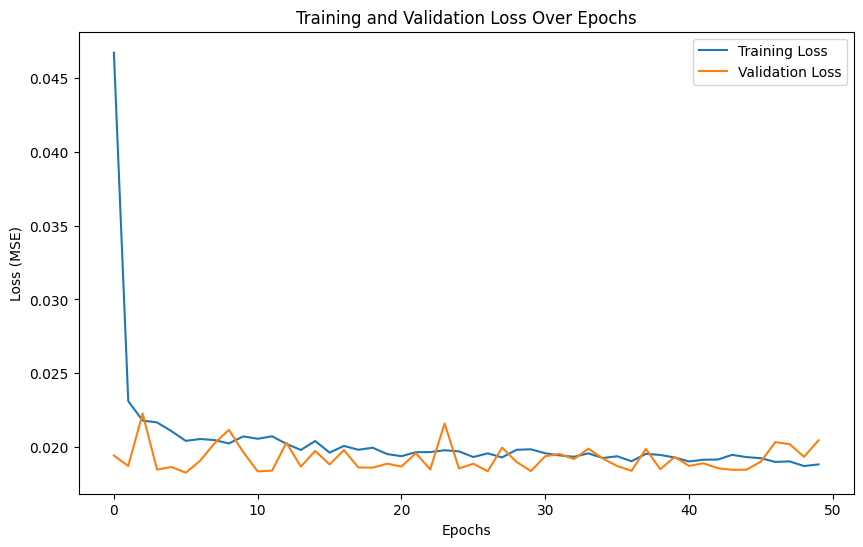

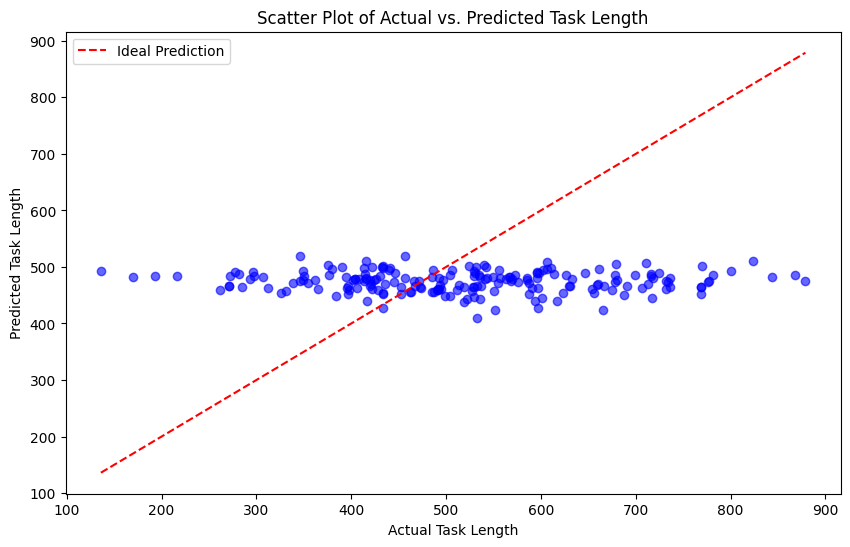

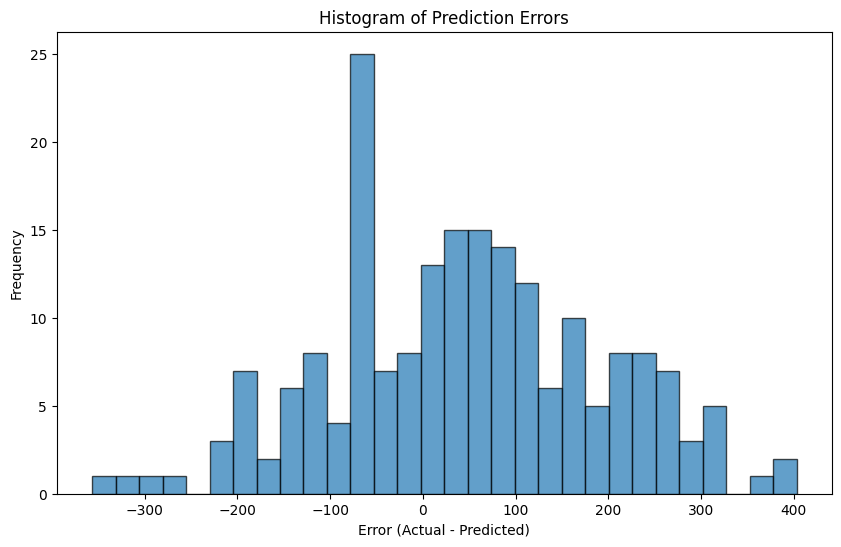

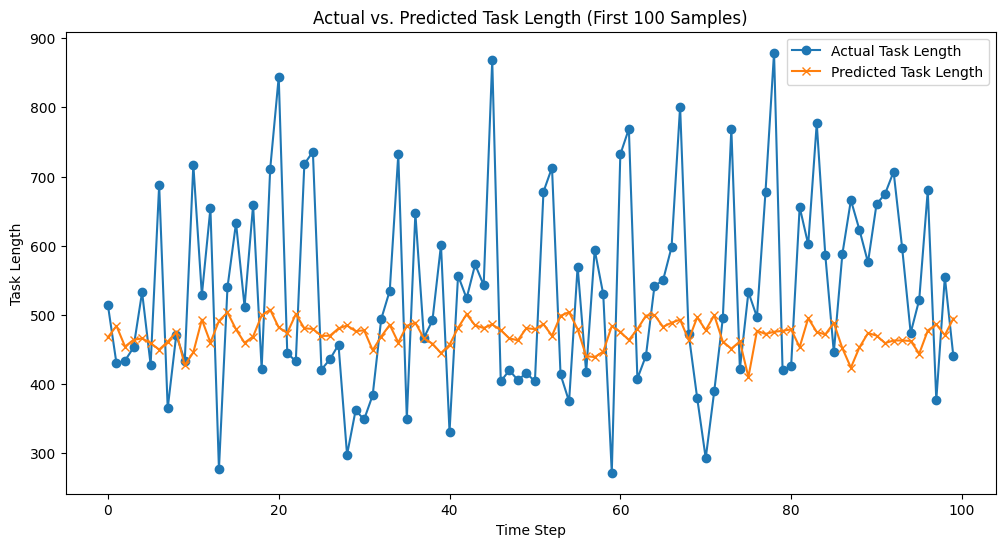

In [3]:
# Additional Charts and Plots for Results and Analysis

# 1. Training and Validation Loss over Epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.show()

# 2. Scatter Plot of Actual vs. Predicted Task Length
plt.figure(figsize=(10, 6))
plt.scatter(y_test_inv, predictions_inv.flatten(), alpha=0.6, color='b')
plt.xlabel("Actual Task Length")
plt.ylabel("Predicted Task Length")
plt.title("Scatter Plot of Actual vs. Predicted Task Length")
# Plot a reference line (ideal predictions)
min_val = min(y_test_inv.min(), predictions_inv.min())
max_val = max(y_test_inv.max(), predictions_inv.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
plt.legend()
plt.show()

# 3. Histogram of Prediction Errors (Residuals)
errors = y_test_inv - predictions_inv.flatten()
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Errors")
plt.show()

# 4. Zoomed-In Time Series Plot (First 100 Samples)
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:100], label='Actual Task Length', marker='o')
plt.plot(predictions_inv[:100], label='Predicted Task Length', marker='x')
plt.xlabel("Time Step")
plt.ylabel("Task Length")
plt.title("Actual vs. Predicted Task Length (First 100 Samples)")
plt.legend()
plt.show()
